<a href="https://colab.research.google.com/github/edpagaelmejor/challenge/blob/main/CAERTERA_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importar archivo a colab
from google.colab import files
uploaded = files.upload()

# importar librerias pandas numpy maplolit streamlit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
##import streamlit as st
import plotly.express as px



Saving Prueba especialista Candidatos.xlsx to Prueba especialista Candidatos (1).xlsx


In [ ]:
### mostrar las hojas en el excel
excel = pd.ExcelFile('Prueba especialista Candidatos.xlsx')
excel.sheet_names

['Instrucciones Candidato',
 'BASE TOTAL (Sem Actual)',
 'BASE TOTAL (Sem Anterior)']

In [ ]:
#crea un data frame baseactual base anterior con la lectura y la dos hojas
baseactual = pd.read_excel('Prueba especialista Candidatos.xlsx', sheet_name='BASE TOTAL (Sem Actual)')
baseanterior = pd.read_excel('Prueba especialista Candidatos.xlsx', sheet_name='BASE TOTAL (Sem Anterior)')

# imprime las primeros 5 filas tanto de baseactual como baseanteriro
print(baseactual.head(5))
print(baseanterior.head(5))

   Identificacion       Cliente      ZONA ZONA ESPECIFICA VENDEDOR  \
0     990000001.0  Cliente 0001  CASANARE        CASANARE     V017   
1     990000002.0  Cliente 0002  INTERIOR          TOLIMA     V006   
2     990000003.0  Cliente 0003  INTERIOR          TOLIMA     V006   
3     990000004.0  Cliente 0004  CASANARE        CASANARE     V017   
4     990000005.0  Cliente 0005  CASANARE        CASANARE     V017   

   Total Cartera  Cartera Corriente  cartera vencida  Vencida 1 a 30  \
0    450116037.0        450116037.0              0.0             0.0   
1     59504015.0         52741515.0        6762500.0       6762500.0   
2    807661642.0        272203856.0      535457786.0     361788741.0   
3    663160619.0        663160619.0              0.0             0.0   
4     33991754.0         33991754.0              0.0             0.0   

   Vencida 31 a 60  ...  GESTION COBRANZA/ OBSERVACION  Etapa_Corriente  \
0              0.0  ...    paga arroz secano en agosto        450116037

In [ ]:
#Agraga una nuena columa llamada SEMANA, UNA QUE CONTENGA Semanaactual y la otra semanaanterior

baseactual ['SEMANA'] = 'SEMANA ACTUAL'
baseanterior['SEMANA'] ='SEMANA ANTERIOR'

### IMPRIMA SOLO LAS COLUMNAS DEL LOS ENCABEZADOS

print(baseactual.columns)
print(baseanterior.columns)



Index(['Identificacion', 'Cliente', 'ZONA', 'ZONA ESPECIFICA', 'VENDEDOR',
       'Total Cartera', 'Cartera Corriente', 'cartera vencida',
       'Vencida 1 a 30', 'Vencida 31 a 60', 'Vencida 61 a 90',
       'Vencida 91 a 180', 'Vencida 181 a 360', 'Vencida Mayor 360', 'TIPO',
       'COBRO JURIDICO', 'LISTAS NEGRAS', 'REFINANCIADOS EN COBRO JURIDICO',
       'CONCILIACION JURIDICA', 'ACUERDO DE PAGO "O" REFINANCIADO',
       'COMPAÑIAS GRUPO “INTERCOMPANY”', 'OBSERVACION', 'RESPONSABLE',
       'TIPOLOGIA', 'CULTIVO', 'GESTION COBRANZA/ OBSERVACION',
       'Etapa_Corriente', 'Etapa_Administrativa', 'Etapa_Prejuridica',
       'Etapa_Precritica', 'Etapa_AcuerdoPago', 'Etapa_Juridica',
       'Etapa_RefJuridico', 'Columna1', 'Columna2', 'SEMANA'],
      dtype='object')
Index(['Identificacion', 'Cliente', 'ZONA', 'ZONA ESPECIFICA', 'VENDEDOR',
       'Total Cartera', 'Cartera Corriente', 'cartera vencida',
       'Vencida 1 a 30', 'Vencida 31 a 60', 'Vencida 61 a 90',
       'Vencida 9

In [ ]:
### ahora necesito unir las dos hojas como siperagar una debajo de la otra
df_union = pd.concat([baseactual, baseanterior])
df_union.head(3)

,Identificacion,Cliente,ZONA,ZONA ESPECIFICA,VENDEDOR,Total Cartera,Cartera Corriente,cartera vencida,Vencida 1 a 30,Vencida 31 a 60,...,Etapa_Administrativa,Etapa_Prejuridica,Etapa_Precritica,Etapa_AcuerdoPago,Etapa_Juridica,Etapa_RefJuridico,Columna1,Columna2,SEMANA,TIPOLOGIA_LIMPIA
0,990000001.0,Cliente 0001,CASANARE,CASANARE,V017,450116037.0,450116037.0,0.0,0.0,0.0,...,0,0,0,0,0,0,450116037.0,0.0,SEMANA ACTUAL,NaN
1,990000002.0,Cliente 0002,INTERIOR,TOLIMA,V006,59504015.0,52741515.0,6762500.0,6762500.0,0.0,...,6762500,0,0,0,0,0,59504015.0,0.0,SEMANA ACTUAL,NaN
2,990000003.0,Cliente 0003,INTERIOR,TOLIMA,V006,807661642.0,272203856.0,535457786.0,361788741.0,96540320.0,...,361788741,173669045,0,0,0,0,807661642.0,0.0,SEMANA ACTUAL,NaN


In [ ]:
## Necesito agrupar  porzona especifica
df_agruparpor_zona =df_union['ZONA ESPECIFICA'].unique()
##print(df_agruparpor_zona)
Total_cartera_vencidad = df_union.groupby('ZONA ESPECIFICA')['cartera vencida'].sum()
print(Total_cartera_vencidad)



['CASANARE' 'TOLIMA' 'ALTILLANURA' 'HUILA' 'META' 'INTERCOMPANY' 'COSTA'
 'CANAL MAYORISTA' 'NORTE DE SANTANDER' nan]
ZONA ESPECIFICA
ALTILLANURA           4.963452e+10
CANAL MAYORISTA       1.953438e+08
CASANARE              3.432924e+10
COSTA                 1.672067e+09
HUILA                 9.950033e+09
INTERCOMPANY          2.749494e+10
META                  1.657068e+10
NORTE DE SANTANDER    4.888105e+07
TOLIMA                5.064765e+10
Name: cartera vencida, dtype: float64


<BarContainer object of 9 artists>

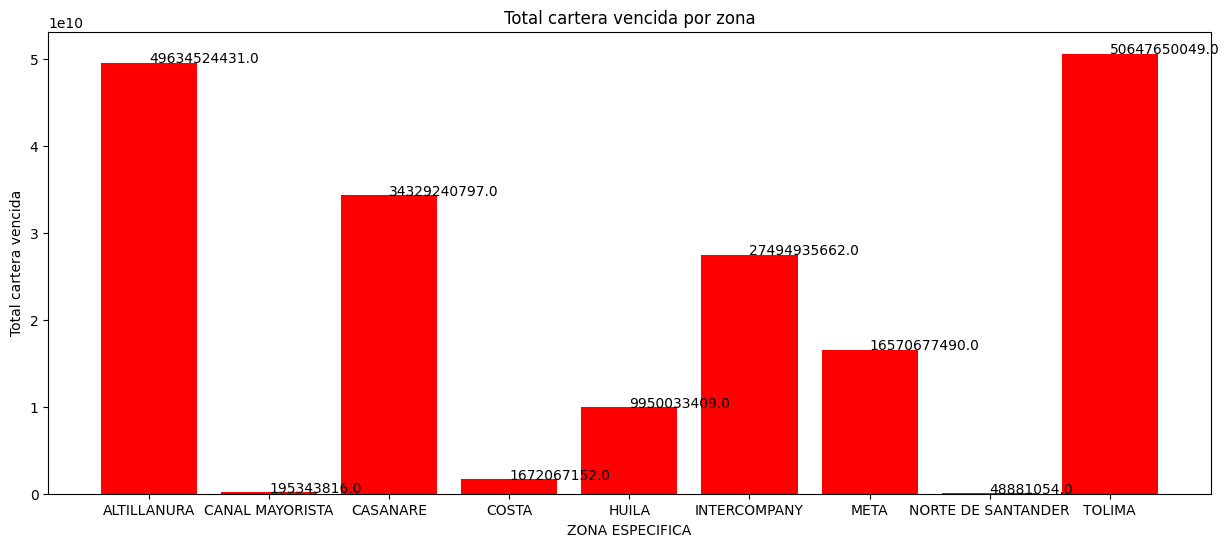

In [ ]:
# vamos graficar con maptloli unagrafica de barras zona esfecitica y carteravencidad


plt.figure(figsize=(15, 6))
plt.title('Total cartera vencida por zona')
plt.xlabel('ZONA ESPECIFICA')
plt.ylabel('Total cartera vencida')
### Etiqueta de datos
for i in Total_cartera_vencidad.index:
  plt.text(i, Total_cartera_vencidad[i], Total_cartera_vencidad[i])

plt.bar(Total_cartera_vencidad.index, Total_cartera_vencidad.values,color='red')


In [ ]:
## SNSTALAR STREAMLIT
!pip install -q streamlit
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 24.8 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
added 22 packages in 3s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧

In [ ]:
### creacion de
%%writefile app.py
import streamlit as st

st.title("Mi Aplicación desde Colab 🚀")
st.write("¡Hola! Esta app está corriendo desde Google Colab usando Streamlit y LocalTunnel.")
st.slider("Selecciona un valor", 0, 100, 50)

Overwriting app.py
